In [228]:
# %%capture  # supress output
# %pip install fastai
# %pip install ipywidgets


In [229]:
from ipywidgets import interact
from fastai.basics import *

# defining runtime config of plots (figure in our case)
plt.rc("figure", dpi=90)

In [230]:
def plot_funciton(f, title=None, min=-5.1, max=12.1, color="r", ylim=None):
    x = torch.linspace(min, max, 100)[:, None]
    if ylim:
        plt.ylim(ylim)
    plt.plot(x, f(x), color)
    if title is not None:
        plt.title(title)

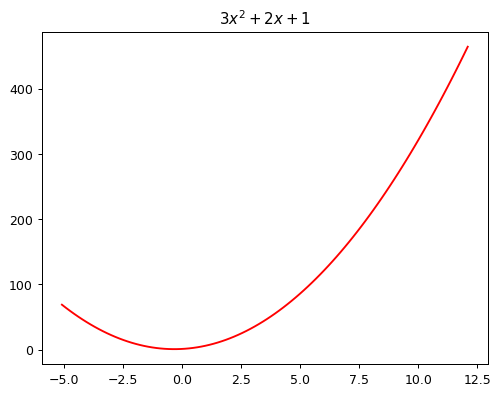

In [231]:
def f(x):
    return 3 * x**2 + 2 * x + 1


plot_funciton(f, "$3x^2+2x+1$")

Make a quadratic function

In [232]:
def quad(a, b, c, x):
    return a * x**2 + b * x + c

Make the quadtratic function dynamic

In [233]:
def mk_quad(a, b, c):
    return partial(quad, a, b, c)

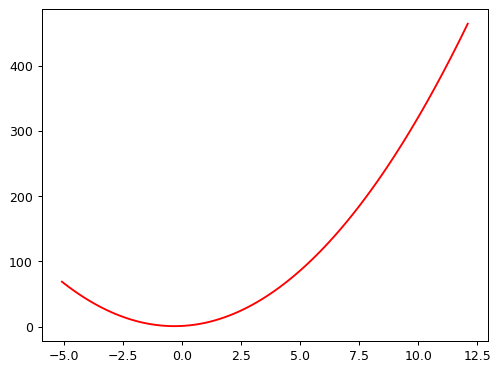

In [234]:
f2 = mk_quad(3, 2, 1)
plot_funciton(f2)  # values of x are defined in the plot_fucntion

create function for adding noise

In [235]:
def noise(x, scale):
    return np.random.normal(scale=scale, size=x.shape)


def add_noise(x, mult, add):
    return x * (1 + noise(x, mult)) + noise(x, add)

In [236]:
np.random.seed(42)
x = torch.linspace(-2.1, 2.1, steps=20)[:, None]
y = add_noise(f(x), 0.15, 1.5)

/tmp/ipykernel_12320/1945435617.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return x * (1 + noise(x, mult)) + noise(x, add)


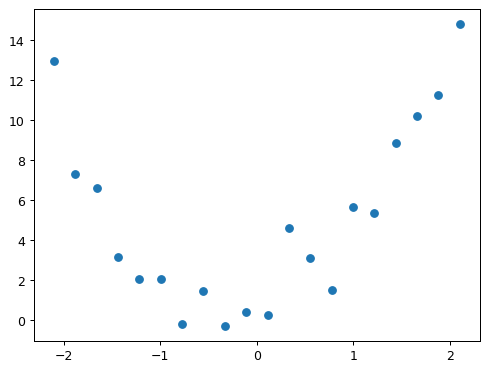

In [237]:
plt.scatter(x, y)

In [238]:
@interact(a=1.1, b=1.1, c=1.1)
def plot_quad(a, b, c):
    plt.scatter(x, y)
    plot_funciton(mk_quad(a, b, c), ylim=(-1, 15))

interactive(children=(FloatSlider(value=1.1, description='a', max=3.3000000000000003, min=-1.1), FloatSlider(v…

In [239]:
def mae(preds,acts): return torch.abs(preds-acts).mean()

In [240]:
@interact(a=1.1, b=1.1, c=1.1)
def plot_quad(a, b, c):
    f = mk_quad(a,b,c)
    plt.scatter(x,y)
    loss = mae(f(x), y)
    plot_funciton(f, ylim=(-3,12), title=f"MAE: {loss:.2f}")

interactive(children=(FloatSlider(value=1.1, description='a', max=3.3000000000000003, min=-1.1), FloatSlider(v…

Automating Gradient Descend

In [241]:
def quad_mae(params):
    f = mk_quad(*params)
    return mae(f(x), y)

In [242]:
# let's try this
quad_mae([1.1, 1.1, 1.1])

tensor(2.6662, dtype=torch.float64)

In [243]:
abc = torch.tensor([1.1, 1.1, 1.1])

In [244]:
abc.requires_grad_()

tensor([1.1000, 1.1000, 1.1000], requires_grad=True)

In [245]:
loss = quad_mae(abc)
loss

tensor(2.6662, dtype=torch.float64, grad_fn=<MeanBackward0>)

In [246]:
loss.backward()

In [247]:
abc.grad

tensor([-1.4916, -0.0332, -0.5000])

In [248]:
# with torch.no_grad():
#     abc = abc - abc.grad * 0.01
#     print(f'req grad',abc.requires_grad)
#     print(f"abc={abc}")
#     loss = quad_mae(abc)

# print(f"loss={loss:.3f}")

In [249]:
for i in range(20):
    loss = quad_mae(abc)
    loss.backward()
    with torch.no_grad():
        abc -= abc.grad * 0.01
    print(f"step: {i} --- loss: {loss:.2f} --- grads: {abc.grad}")

step: 0 --- loss: 2.67 --- grads: tensor([-2.9832, -0.0663, -1.0000])
step: 1 --- loss: 2.62 --- grads: tensor([-4.4747, -0.0995, -1.5000])
step: 2 --- loss: 2.54 --- grads: tensor([-5.9663, -0.1326, -2.0000])
step: 3 --- loss: 2.44 --- grads: tensor([-7.4579, -0.1658, -2.5000])
step: 4 --- loss: 2.32 --- grads: tensor([-8.9495, -0.1989, -3.0000])
step: 5 --- loss: 2.17 --- grads: tensor([-10.4411,  -0.2321,  -3.5000])
step: 6 --- loss: 2.00 --- grads: tensor([-11.7848,  -0.3868,  -3.9000])
step: 7 --- loss: 1.83 --- grads: tensor([-13.1286,  -0.5416,  -4.3000])
step: 8 --- loss: 1.65 --- grads: tensor([-14.2659,  -0.8400,  -4.6000])
step: 9 --- loss: 1.49 --- grads: tensor([-15.1565,  -1.1163,  -4.7000])
step: 10 --- loss: 1.35 --- grads: tensor([-16.0470,  -1.3926,  -4.8000])
step: 11 --- loss: 1.21 --- grads: tensor([-16.5540,  -1.5363,  -4.7000])
step: 12 --- loss: 1.17 --- grads: tensor([-16.7079,  -1.8679,  -4.5000])
step: 13 --- loss: 1.21 --- grads: tensor([-16.1460,  -1.8237, 

How a neural network approximates any given function

In [250]:
def rectified_linear(m, b, x):
    y = m*x +b
    return torch.clip(y, 0.) 

In [251]:
# test the funciton
rectified_linear(1,1, torch.tensor(-2))

tensor(0.)

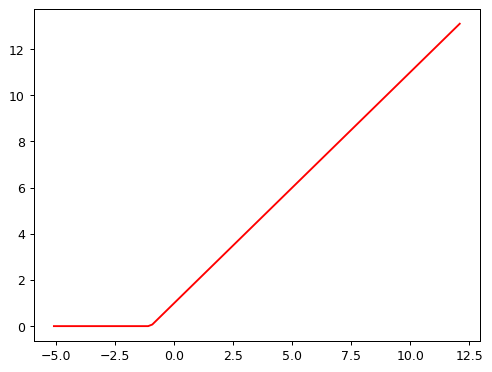

In [252]:
plot_funciton(partial(rectified_linear, 1, 1))

In [253]:
# let's make the plot interactive
@interact(m=1.5, b=1.5)
def plot_relu(m, b):
    plot_funciton(partial(rectified_linear, m, b), ylim=(-1, 4))

interactive(children=(FloatSlider(value=1.5, description='m', max=4.5, min=-1.5), FloatSlider(value=1.5, descr…

In [254]:
def double_relu(m1,b1,m2,b2,x):
    return rectified_linear(m1,b1,x) + rectified_linear(m2,b2,x)

@interact(m1=-1.5, b1=-1.5, m2=1.5, b2=1.5)
def plot_double_relu(m1, b1, m2, b2):
    plot_funciton(partial(double_relu, m1,b1,m2,b2), ylim=(-1,6))

interactive(children=(FloatSlider(value=-1.5, description='m1', max=1.5, min=-4.5), FloatSlider(value=-1.5, de…

In [255]:
def triple_relu(m1, b1, m2, b2, m3, b3, x):
    return (
        rectified_linear(m1, b1, x)
        + rectified_linear(m2, b2, x)
        + rectified_linear(m3, b3, x)
    )


@interact(m1=-1.5, b1=-1.5, m2=1.5, b2=1.5, m3=1.5, b3=1.5)
def plot_triple_relu(m1, b1, m2, b2, m3, b3):
    plot_funciton(partial(triple_relu, m1, b1, m2, b2, m3, b3), ylim=(-1, 10))

interactive(children=(FloatSlider(value=-1.5, description='m1', max=1.5, min=-4.5), FloatSlider(value=-1.5, de…

In [256]:
def ten_relu(m1, b1, m2, b2, m3, b3, m4, b4, m5, b5,
             m6, b6, m7, b7, m8, b8, m9, b9, m10, b10, x):
    return (
        rectified_linear(m1,  b1,  x)
        + rectified_linear(m2,  b2,  x)
        + rectified_linear(m3,  b3,  x)
        + rectified_linear(m4,  b4,  x)
        + rectified_linear(m5,  b5,  x)
        + rectified_linear(m6,  b6,  x)
        + rectified_linear(m7,  b7,  x)
        + rectified_linear(m8,  b8,  x)
        + rectified_linear(m9,  b9,  x)
        + rectified_linear(m10, b10, x)
    )

@interact(m1=1.5, b1=-3.0, m2=-1.5, b2=2.0, m3=1.0, b3=-1.0,
          m4=-1.0, b4=1.5, m5=0.5, b5=-0.5, m6=-0.5, b6=0.5,
          m7=1.5, b7=-2.0, m8=-1.5, b8=2.5, m9=1.0, b9=-1.5,
          m10=-1.0, b10=1.0)
def plot_ten_relu(m1, b1, m2, b2, m3, b3, m4, b4, m5, b5,
                 m6, b6, m7, b7, m8, b8, m9, b9, m10, b10):
    plot_funciton(partial(ten_relu, m1, b1, m2, b2, m3, b3, m4, b4, m5, b5,
                                   m6, b6, m7, b7, m8, b8, m9, b9, m10, b10),
                  ylim=(-5, 70))

interactive(children=(FloatSlider(value=1.5, description='m1', max=4.5, min=-1.5), FloatSlider(value=-3.0, des…